## Exporting quality control for exploring and plotting in R

Load library

In [1]:
# Path-related libraries
import os
from pyhere import here  # For reproducible relative paths
import sys # system specific parameters
from pathlib import Path # File system paths

# AnnData and single-cell analysis libraries
import scanpy as sc       # For preprocessing and visualization of single-cell data
import anndata as ad      # For handling AnnData objects

# Numerical operations
import numpy as np        # For numerical computations and array manipulations
import pandas as pd

# Custom modules and functions
sys.path.append(str(here('scripts/misc')))  # Add custom script path to system
import my_anndata as ma                    # Custom AnnData utilities

Parameters

In [2]:
# save paths
base_dir = str(here('data/integrate/second_pass/'))
plot_dir = os.path.join(base_dir, 'plot') 
files_dir = os.path.join(base_dir, 'files') 
objects_dir = os.path.join(base_dir, 'objects') 

Import data

In [14]:
# AnnData object
adata = ad.read_h5ad(os.path.join(objects_dir, 'AB_adata_full_with_latent.h5ad'))
doublet_probs = pd.read_csv(os.path.join(files_dir, 'doublet_probabilities.csv'), index_col= 'barcode')
module_score = pd.read_csv(os.path.join(files_dir, 'marker_gene_scores.csv'), index_col= 0)[[column for column in module_score.columns if column.startswith('azimuth')]]

Combine adata obs with doublet probabilities and module scores, and save as csv

In [17]:
adata_obs = adata.obs.copy()
adata_obs = adata_obs.join(module_score)
adata_obs = adata_obs.join(
    doublet_probs[["doublet_probability"]],
    how="left")
# save as csv
adata_obs.to_csv(os.path.join(files_dir, 'adata_obs.csv'), index_label='barcode')

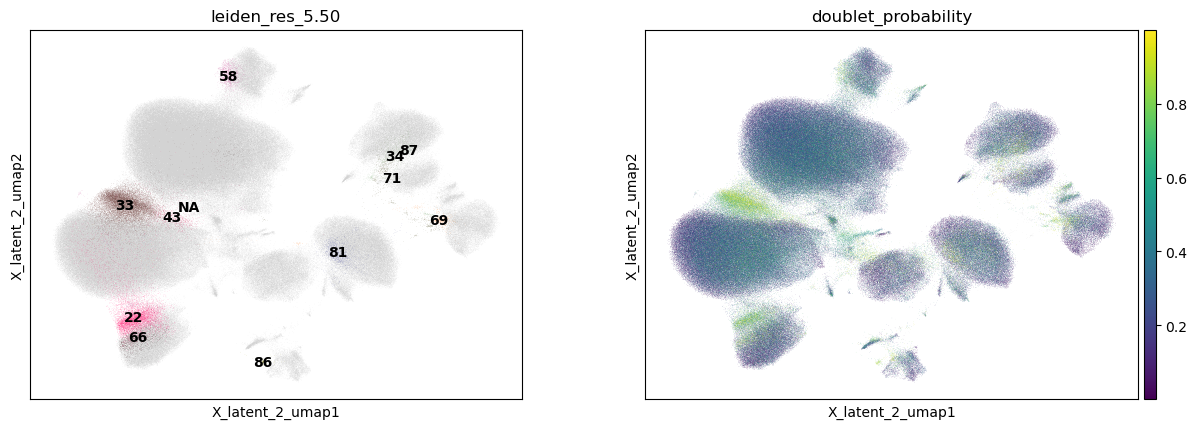

In [35]:
clusters = ["22", "33", "34", "43", "58", "66", "69", "71", "81", "86", "87"]
clusters = ["16", "25", "27", "32", "51", "52", "54", "55", "58"]
sc.pl.embedding(adata, basis = 'X_latent_2_umap', groups = clusters, color = ['leiden_res_4.50', 'doublet_probability'], legend_loc="on data")

In [33]:
adata.obs = adata.obs.join(
    doublet_probs[["doublet_probability"]],
    how="left")



In [45]:
adata.shape

(589202, 60656)

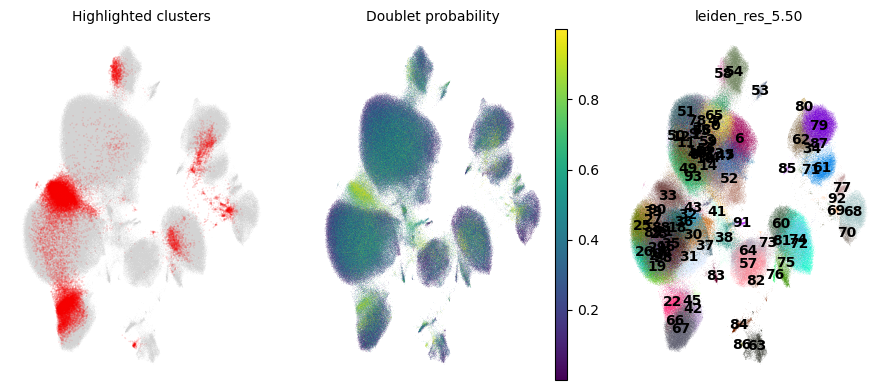

In [66]:
import matplotlib.pyplot as plt
clusters = ["22", "33", "34", "43", "58", "66", "69", "71", "81", "86", "87"]


n_cells, _ = adata.shape
subset = adata[adata.obs["leiden_res_5.50"].isin(clusters)]

fig, axes = plt.subplots(1, 3, figsize=(9, 4))
sc.pl.embedding(adata, basis="X_latent_2_umap", color=None, palette=["lightgray"],
                ax=axes[0], show=False, frameon=False)
axes[0].scatter(subset.obsm["X_latent_2_umap"][:, 0],
                subset.obsm["X_latent_2_umap"][:, 1],
                facecolors='none', edgecolors='red', linewidths=0.8,
                s=1200/n_cells)
axes[0].set_title("Highlighted clusters", fontsize=10)

sc.pl.embedding(adata, basis="X_latent_2_umap", color="doublet_probability",
                ax=axes[1], show=False, frameon=False)
axes[1].set_title("Doublet probability", fontsize=10)

sc.pl.embedding(adata, basis="X_latent_2_umap", color="leiden_res_5.50",
                ax=axes[2], show=False, frameon=False, legend_loc="on data")
axes[2].set_title("leiden_res_5.50", fontsize=10)

plt.tight_layout()
plt.show()